In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *
from sklearn.metrics import accuracy_score

# Load the preprocessed data
train_df = pd.read_csv('../../data/classification/processed/dry_bean/train_scaled.csv')
val_df = pd.read_csv('../../data/classification/processed/dry_bean/val_scaled.csv')
test_df = pd.read_csv('../../data/classification/processed/dry_bean/test_scaled.csv')

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values
X_val = val_df.iloc[:, :-1].values
y_val = val_df.iloc[:, -1].values
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (9480, 16), Test size: (2032, 16)


# I. Logistic Regression (nhị phân và đa lớp)

## 1. Biểu thức toán học Logistic Regression
### Gradient và Hessian:
- Gradient của Softmax (cross-entropy direct multinomial): $\nabla E = \frac{1}{N} \sum_{n=1}^N (\mathbf{y}_n - \mathbf{t}_n)\mathbf{x}_n^T$ 
- Hessian cho Binary LR (để tính Newton-Raphson): $H = \Phi^T R \Phi$ nơi $R = diag(y_n(1 - y_n))$.
Việc sử dụng phương pháp **Newton-Raphson (IRLS)** tốn nhiều chi phí vì thao tác nghịch đảo ma trận $H$ kích thước $(D+1, D+1)$, dẫn đến giới hạn của việc huấn luyện trên tập Features siêu đa chiều.

## 2. Thí nghiệm Binary: Gradient Descent vs Newton-Raphson
Gián lược bài toán K=7 thành Binary thông qua việc lọc 2 loại đậu phổ biến nhất là DERMASON (5) và SIRA (6) để quan sát hội tụ Hessian và Gradient.

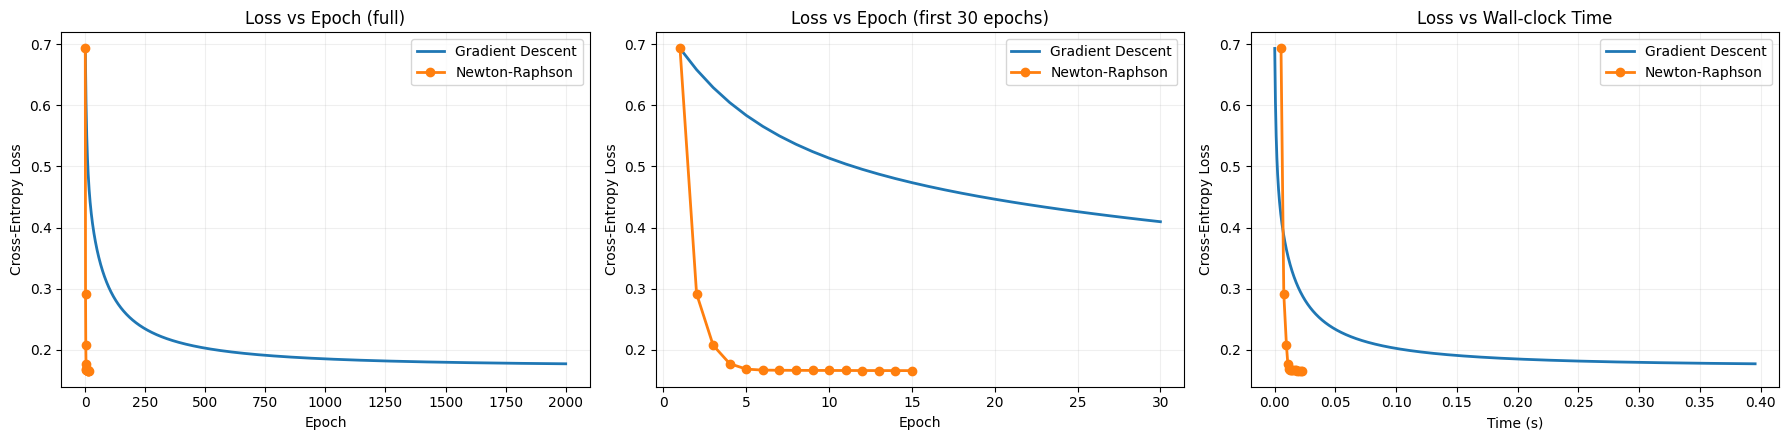

Epochs to converge - GD: 2000
Epochs to converge - Newton-Raphson: 15
Total training time - GD: 0.3956 s
Total training time - Newton-Raphson: 0.0229 s
Accuracy Gradient Descent: 0.9266
Accuracy Newton-Raphson: 0.9310


In [35]:
import time

# Get 2 class names for binary classification
mask_train = (y_train == 'DERMASON') | (y_train == 'SIRA')
mask_val = (y_val == 'DERMASON') | (y_val == 'SIRA')

X_bin_train, y_bin_train = X_train[mask_train], y_train[mask_train]
X_bin_val, y_bin_val = X_val[mask_val], y_val[mask_val]

# Encode labels: SIRA=0, DERMASON=1
y_bin_train = (y_bin_train == 'SIRA').astype(int)
y_bin_val = (y_bin_val == 'SIRA').astype(int)

# Model 1: Gradient Descent
gd_start = time.time()
model_gd = LogisticRegressionGD(learning_rate=0.1, max_epochs=2000)
model_gd.fit(X_bin_train, y_bin_train)
gd_total_time = time.time() - gd_start

# Model 2: Newton-Raphson
nt_start = time.time()
model_nt = LogisticRegressionNewton(max_epochs=15, tol=1e-5)
model_nt.fit(X_bin_train, y_bin_train)
nt_total_time = time.time() - nt_start

# Compare convergence speed by loss vs epoch
epochs_gd = np.arange(1, len(model_gd.loss_history) + 1)
epochs_nt = np.arange(1, len(model_nt.loss_history) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Full training trajectory
axes[0].plot(epochs_gd, model_gd.loss_history, label='Gradient Descent', lw=2)
axes[0].plot(epochs_nt, model_nt.loss_history, marker='o', label='Newton-Raphson', lw=2)
axes[0].set_title('Loss vs Epoch (full)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Zoom on first epochs for fair visual comparison
zoom_epochs = min(30, len(model_gd.loss_history))
axes[1].plot(epochs_gd[:zoom_epochs], model_gd.loss_history[:zoom_epochs], label='Gradient Descent', lw=2)
axes[1].plot(epochs_nt, model_nt.loss_history, marker='o', label='Newton-Raphson', lw=2)
axes[1].set_title(f'Loss vs Epoch (first {zoom_epochs} epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(alpha=0.2)

# Loss vs wall-clock time
if hasattr(model_gd, 'wall_clock_time') and len(model_gd.wall_clock_time) == len(model_gd.loss_history):
    gd_time_axis = np.array(model_gd.wall_clock_time)
else:
    # Fallback: approximate timeline from total fit time when per-epoch timestamps are unavailable.
    gd_time_axis = np.linspace(0, gd_total_time, len(model_gd.loss_history), endpoint=True)

if hasattr(model_nt, 'wall_clock_time') and len(model_nt.wall_clock_time) == len(model_nt.loss_history):
    nt_time_axis = np.array(model_nt.wall_clock_time)
else:
    nt_time_axis = np.linspace(0, nt_total_time, len(model_nt.loss_history), endpoint=True)

axes[2].plot(gd_time_axis, model_gd.loss_history, label='Gradient Descent', lw=2)
axes[2].plot(nt_time_axis, model_nt.loss_history, marker='o', label='Newton-Raphson', lw=2)
axes[2].set_title('Loss vs Wall-clock Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Cross-Entropy Loss')
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Epochs to converge - GD: {len(model_gd.loss_history)}")
print(f"Epochs to converge - Newton-Raphson: {len(model_nt.loss_history)}")
print(f"Total training time - GD: {gd_total_time:.4f} s")
print(f"Total training time - Newton-Raphson: {nt_total_time:.4f} s")
print(f"Accuracy Gradient Descent: {accuracy_score(y_bin_val, model_gd.predict(X_bin_val)):.4f}")
print(f"Accuracy Newton-Raphson: {accuracy_score(y_bin_val, model_nt.predict(X_bin_val)):.4f}")

- Có thể thấy Newton-Raphson hội tụ cực nhanh theo epoch khi chỉ cần khoảng 5-6 epochs đã gần như hội tụ trong khi GD cần tới hàng nghìn
- Theo thời gian, có thể thấy Newton-Raphson hội tụ chậm hơn trong khoảng 0,01 giây đầu nhưng sau đó nhanh chóng vượt mặt GD

## 3. Thí nghiệm Multi-class (7 Classes): OVR, OVO, Softmax
Thực chiến lại độ hiệu quả thuật toán trực tiếp trên toàn bộ dữ liệu 7 lớp gốc kết hợp với base module (Binary Gradient Descent).
`OneVsOne` (OVO) sẽ tiêu tốn thời gian hơn đáng kể vì đòi hỏi phải training tới $\frac{7 \times 6}{2} = 21$ networks độc lập.

In [ ]:
import time

base_lr = LogisticRegressionGD(learning_rate=0.1, max_epochs=500, class_weight='balanced')

print("Training One-Vs-Rest...")
ovr_model = OneVsRestClassifier(estimator=base_lr)
t_start = time.time(); ovr_model.fit(X_train, y_train); t_ovr = time.time() - t_start

print("Training One-Vs-One...")
ovo_model = OneVsOneClassifier(estimator=base_lr)
t_start = time.time(); ovo_model.fit(X_train, y_train); t_ovo = time.time() - t_start

print("Training Softmax (Multinomial direct)...")
softmax_model = LogisticRegressionGD(
    learning_rate=0.1,
    max_epochs=500,
    multi_class='multinomial',
    class_weight='balanced',
)
t_start = time.time(); softmax_model.fit(X_train, y_train); t_soft = time.time() - t_start

acc_ovr = accuracy_score(y_val, ovr_model.predict(X_val))
acc_ovo = accuracy_score(y_val, ovo_model.predict(X_val))
acc_soft = accuracy_score(y_val, softmax_model.predict(X_val))

results = pd.DataFrame({
    'Strategy': ['OVR', 'OVO', 'Softmax'],
    'Accuracy': [acc_ovr, acc_ovo, acc_soft],
    'Time (s)': [t_ovr, t_ovo, t_soft]
})
results

Training One-Vs-Rest...
Training One-Vs-One...
Training Softmax (Multinomial direct)...


,Strategy,Accuracy,Time (s)
0,OVR,0.848351,1.503893
1,OVO,0.908912,1.645525
2,Softmax,0.887740,2.248093


- Có thể thấy trong trường hợp này, OVO là tối ưu nhất cả về thời gian và hiệu suất

## 4. Trình bày đầy đủ đạo hàm Hessian, Jacobian của softmax

### Ký hiệu
Cho vector logits $\mathbf{z}\in\mathbb{R}^K$, softmax:
$$
\mathbf{s}=\operatorname{softmax}(\mathbf{z}),\qquad
s_i=\frac{e^{z_i}}{\sum_{m=1}^K e^{z_m}}.
$$

### Jacobian của softmax
Đạo hàm phần tử:
$$
\frac{\partial s_i}{\partial z_j}
= s_i\,(\delta_{ij}-s_j).
$$
Suy ra Jacobian $J\in\mathbb{R}^{K\times K}$ có phần tử:
$$
J_{ij}=s_i(\delta_{ij}-s_j).
$$
Dạng ma trận gọn:
$$
J=\operatorname{diag}(\mathbf{s})-\mathbf{s}\mathbf{s}^\top.
$$

### Hessian của softmax (đầy đủ)
Vì $s_i$ là hàm vô hướng theo $\mathbf{z}$, với mỗi $i$ ta có một Hessian $H^{(i)}\in\mathbb{R}^{K\times K}$:
$$
H^{(i)}_{jk}=\frac{\partial^2 s_i}{\partial z_j\partial z_k}.
$$
Từ $\frac{\partial s_i}{\partial z_j}=s_i(\delta_{ij}-s_j)$:
$$
\frac{\partial^2 s_i}{\partial z_j\partial z_k}
= s_i(\delta_{ik}-s_k)(\delta_{ij}-s_j)-s_i s_j(\delta_{jk}-s_k).
$$
Tương đương:
$$
H^{(i)}_{jk}
= s_i\Big[(\delta_{ij}-s_j)(\delta_{ik}-s_k)-s_j(\delta_{jk}-s_k)\Big].
$$

# II. Linear Discriminant Analysis – LDA và QDA

## 1. LDA và QDA

In [20]:
# Encode labels for LDA/QDA

y_train_raw = y_train

# Get unique class names and create mappings
class_names = np.sort(np.unique(y_train_raw))
label_to_int = {label: idx for idx, label in enumerate(class_names)}
int_to_label = {idx: label for label, idx in label_to_int.items()}

y_train_t = np.array([label_to_int[label] for label in y_train_raw], dtype=int)
if y_test is not None:
    y_test = np.array([label_to_int.get(label, -1) for label in y_test], dtype=int)
    if np.any(y_test == -1):
        unknown = np.unique(y_test[y_test == -1])
        raise ValueError(f"Test set labels not in train train: {unknown}")
else:
    y_test = None
    
# ---- LDA ----
lda = LDA_Scratch()
lda.fit(X_train, y_train_t)
y_pred_lda = lda.predict(X_test)
if y_test is not None:
    print('LDA test accuracy:', accuracy(y_test, y_pred_lda))
    display(confusion_matrix_df(y_test, y_pred_lda, class_names))
else:
    print('Finished training LDA. Test set has no labels, showing prediction distribution:')
    values, counts = np.unique(y_pred_lda, return_counts=True)
    display(pd.DataFrame({'Class': class_names[values], 'Count': counts}).sort_values('Count', ascending=False))

# ---- QDA ----
qda = QDA_Scratch()
qda.fit(X_train, y_train_t)
y_pred_qda = qda.predict(X_test)
if y_test is not None:
    print('QDA test accuracy:', accuracy(y_test, y_pred_qda))
    display(confusion_matrix_df(y_test, y_pred_qda, class_names))
else:
    print('Finished training QDA. Test set has no labels, showing prediction distribution:')
    values, counts = np.unique(y_pred_qda, return_counts=True)
    display(pd.DataFrame({'Class': class_names[values], 'Count': counts}).sort_values('Count', ascending=False))

LDA test accuracy: 0.8976377952755905


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
BARBUNYA,169,0,17,0,0,3,9
BOMBAY,0,78,0,0,0,0,0
CALI,8,0,228,0,5,0,4
DERMASON,0,0,0,437,0,12,83
HOROZ,0,0,16,2,254,0,7
SEKER,1,0,0,2,0,286,15
SIRA,0,0,0,18,5,1,372


QDA test accuracy: 0.8976377952755905


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
BARBUNYA,176,0,11,0,1,5,5
BOMBAY,0,78,0,0,0,0,0
CALI,6,0,232,0,4,0,3
DERMASON,0,0,0,416,2,2,112
HOROZ,0,0,11,2,264,0,2
SEKER,1,0,1,5,0,280,17
SIRA,0,0,1,10,7,0,378


## 2. Tính Fisher ratio J(w) cho từng đặc trưng, xếp hạng độ phân biệt lớp.

In [21]:
feature_names = train_df.drop(columns=['Class']).columns.to_list()

ranked_indices, fisher_scores = rank_features_fisher(X_train, y_train, feature_names)

fisher_df = pd.DataFrame({
    'feature': feature_names,
    'fisher_J': fisher_scores,
}).sort_values('fisher_J', ascending=False).reset_index(drop=True)

display(fisher_df)

Ranking features by Fisher Ratio J(w):
1. Perimeter (J = 6.6412)
2. MajorAxisLength (J = 6.6321)
3. ShapeFactor2 (J = 6.2617)
4. ConvexArea (J = 5.8794)
5. EquivDiameter (J = 5.8157)
6. Area (J = 5.8047)
7. ShapeFactor3 (J = 4.5162)
8. Compactness (J = 4.5089)
9. AspectRation (J = 4.4146)
10. MinorAxisLength (J = 4.3640)
11. Eccentricity (J = 4.2958)
12. ShapeFactor1 (J = 4.2629)
13. roundness (J = 3.3640)
14. ShapeFactor4 (J = 1.0717)
15. Solidity (J = 0.4636)
16. Extent (J = 0.1081)


,feature,fisher_J
0,Perimeter,6.641180
1,MajorAxisLength,6.632082
2,ShapeFactor2,6.261740
3,ConvexArea,5.879395
4,EquivDiameter,5.815695
5,Area,5.804702
6,ShapeFactor3,4.516158
7,Compactness,4.508938
8,AspectRation,4.414576
9,MinorAxisLength,4.364026


## 3. Vẽ quy chiếu LDA xuống 2D và biểu diễn đường biên quyết định (decision boundary).

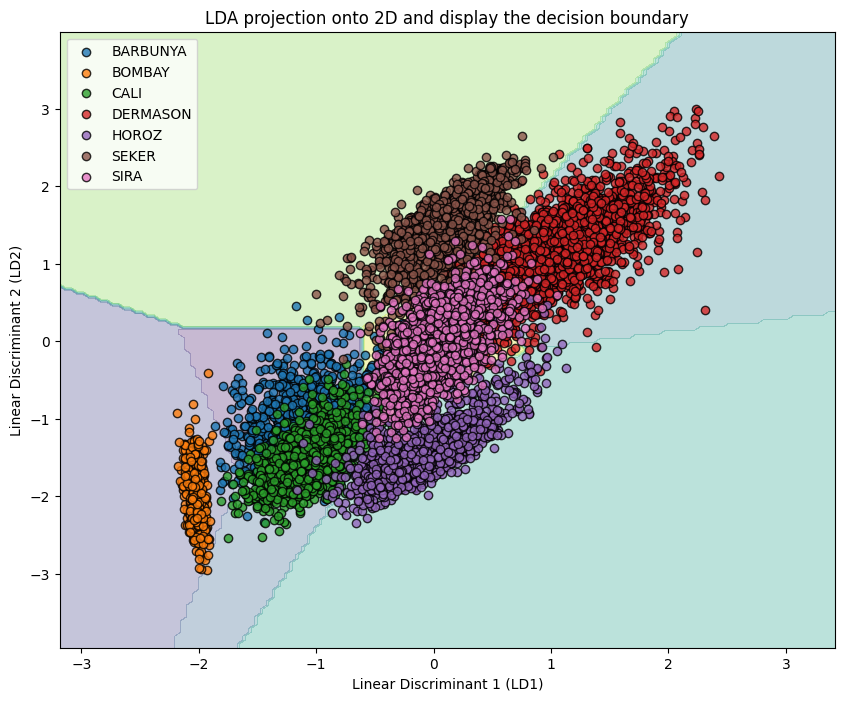

In [22]:
# Draw the LDA projection onto 2D and display the decision boundary.
project_lda_2d_and_plot(X_train, y_train_t, class_names)

## 4. Phân tích khi nào LDA tốt hơn QDA và ngược lại (liên hệ với số mẫu và số chiều).

### Giả định mô hình
- **LDA**: mỗi lớp có phân phối Gaussian với **cùng** ma trận hiệp phương sai $\Sigma$ (chung), khác mean $\mu_k$. Biên quyết định **tuyến tính**.
- **QDA**: mỗi lớp có Gaussian với **ma trận hiệp phương sai riêng** $\Sigma_k$. Biên quyết định **bậc hai** (conic).

### Liên hệ số mẫu $n$, số chiều $d$, số lớp $K$
- Ước lượng hiệp phương sai có số tham số khoảng $\frac{d(d+1)}{2}$.
- **LDA** cần 1 ma trận $\Sigma$ chung $\Rightarrow$ khoảng $\frac{d(d+1)}{2}$ tham số cho covariance.
- **QDA** cần $K$ ma trận $\Sigma_k$ riêng $\Rightarrow$ khoảng $K\cdot\frac{d(d+1)}{2}$ tham số cho covariance.

### Khi nào LDA thường tốt hơn QDA?
- **Ít mẫu / nhiều chiều**: $n$ không đủ lớn so với $d$ (đặc biệt là mỗi lớp $n_k$ nhỏ). QDA phải ước lượng quá nhiều tham số nên dễ **overfit**.
- Khi dữ liệu **gần đúng** thỏa giả định “các lớp có covariance tương tự nhau”. LDA ít tham số nên tổng quát hóa tốt hơn.
- Khi $d$ tăng, việc ước lượng và nghịch đảo $\Sigma_k$ trong QDA có thể **kém ổn định** (dễ gần suy biến) nếu $n_k$ không đủ lớn.

### Khi nào QDA thường tốt hơn LDA?
- **Nhiều mẫu** (đặc biệt là **mỗi lớp** đều có $n_k$ đủ lớn) để ước lượng $\Sigma_k$ ổn định.
- Khi các lớp thực sự có **covariance khác nhau rõ rệt** (hình dạng/độ trải theo các trục khác nhau), biên bậc hai của QDA mô hình hóa tốt hơn.
- Khi ranh giới phân lớp trong không gian đặc trưng là **phi tuyến** theo dạng “đường cong bậc hai” và dữ liệu đủ để học được dạng này.

### Quy tắc kinh nghiệm (heuristic)
- Nếu $n_k$ không “lớn hơn đáng kể” so với $d$ (ví dụ $n_k$ chỉ cỡ vài lần $d$), QDA thường rủi ro hơn LDA.
- Nếu $n$ rất lớn và bạn nghi ngờ covariance khác nhau theo lớp, QDA có cơ hội vượt LDA.

Trong bài này, dữ liệu có $d=16$ và số lớp $K=7$. Bạn có thể so sánh accuracy LDA/QDA trên tập test như ở phần huấn luyện; nếu hai mô hình gần như nhau, đó là dấu hiệu LDA đã đủ tốt hoặc dữ liệu không cần biên bậc hai phức tạp.

# III. Perceptron và Logistic Regression có Regularization

## 1. Thuật toán Perceptron


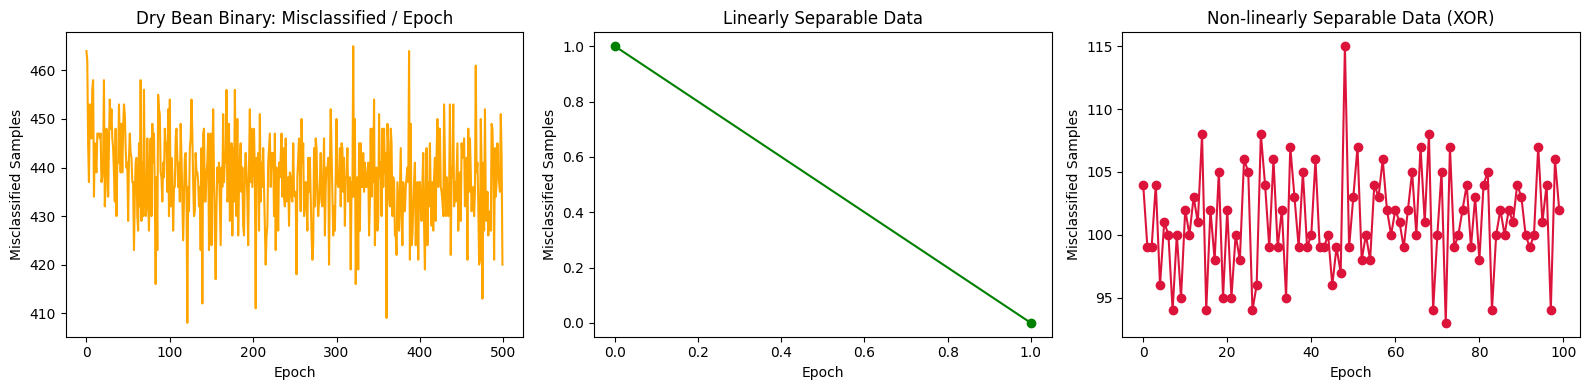

Perceptron Validation Accuracy (Dry Bean): 0.8652
Separable demo converged        : True
Separable demo final mistakes   : 0
Non-separable demo converged    : False
Non-separable demo final mistakes: 102


In [23]:
perceptron = Perceptron(learning_rate=0.01, max_epochs=500)
perceptron.fit(X_bin_train, y_bin_train)
real_val_acc = accuracy_score(y_bin_val, perceptron.predict(X_bin_val))

# 2 dataset separable and non-separable 
X_sep, y_sep = make_perceptron_demo_data(n_samples=200, kind='separable', random_state=42)
X_nonsep, y_nonsep = make_perceptron_demo_data(n_samples=200, kind='non_separable', random_state=42)

perceptron_sep = Perceptron(learning_rate=0.1, max_epochs=100)
perceptron_sep.fit(X_sep, y_sep)

perceptron_nonsep = Perceptron(learning_rate=0.1, max_epochs=100)
perceptron_nonsep.fit(X_nonsep, y_nonsep)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(perceptron.errors_history, color='orange')
axes[0].set_title('Dry Bean Binary: Misclassified / Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Misclassified Samples')

axes[1].plot(perceptron_sep.errors_history, marker='o', color='green')
axes[1].set_title('Linearly Separable Data')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Misclassified Samples')

axes[2].plot(perceptron_nonsep.errors_history, marker='o', color='crimson')
axes[2].set_title('Non-linearly Separable Data (XOR)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Misclassified Samples')

plt.tight_layout()
plt.show()

print(f"Perceptron Validation Accuracy (Dry Bean): {real_val_acc:.4f}")
print(f"Separable demo converged        : {perceptron_sep.errors_history[-1] == 0}")
print(f"Separable demo final mistakes   : {perceptron_sep.errors_history[-1]}")
print(f"Non-separable demo converged    : {perceptron_nonsep.errors_history[-1] == 0}")
print(f"Non-separable demo final mistakes: {perceptron_nonsep.errors_history[-1]}")


## 2. Tinh chỉnh mô hình (Model Tuning) và Tối ưu hóa (Optimization) cho Logistic Regression (LR).

### 2.1 Áp dụng L1 và L2 regularization cho Logistic Regression, so sánh sparsity và hiệu năng.
### 2.2 Chọn $\lambda$ bằng stratified k-fold CV (k = 5) để giữ tỷ lệ lớp trong mỗi fold.
### 2.3 Cài đặt class-weighted loss để xử lý mất cân bằng: $E = \sum_{n,k} c_{k} t_{nk} \ln{y_{nk}}$ với $c_{k} \propto N / N_{k}$


,penalty,C,lambda,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
0,l2,0.10,10.00,0.919807,0.009400,0.923788,0.912240,0.932948,0.906358,0.923699
1,l2,1.00,1.00,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
2,l2,5.00,0.20,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
3,l2,20.00,0.05,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
4,l2,10.00,0.10,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
5,l2,50.00,0.02,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
6,l2,0.01,100.00,0.914261,0.010311,0.915704,0.906467,0.928324,0.899422,0.921387


,penalty,C,lambda,mean_accuracy,std_accuracy,fold_1,fold_2,fold_3,fold_4,fold_5
0,l1,0.10,10.00,0.920500,0.009023,0.922633,0.916859,0.934104,0.906358,0.922543
1,l1,1.00,1.00,0.919806,0.009178,0.923788,0.915704,0.932948,0.905202,0.921387
2,l1,5.00,0.20,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
3,l1,20.00,0.05,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
4,l1,10.00,0.10,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
5,l1,50.00,0.02,0.919575,0.009089,0.922633,0.915704,0.932948,0.905202,0.921387
6,l1,0.01,100.00,0.899005,0.006659,0.905312,0.897229,0.906358,0.887861,0.898266


Best L2 C from stratified 5-fold CV: 0.1 (lambda=10.0000)
Best L1 C from stratified 5-fold CV: 0.1 (lambda=10.0000)
Accuracy No Penalty        : 0.9202
Accuracy L2 (class_weighted) : 0.9191
Accuracy L1 (class_weighted) : 0.9180


,Model,threshold,near_zero_count,total_count,near_zero_ratio
0,No Penalty,0.001,0,16,0.0
1,"L2 (C=0.1, lambda=10.0000)",0.001,0,16,0.0
2,"L1 (C=0.1, lambda=10.0000)",0.001,0,16,0.0


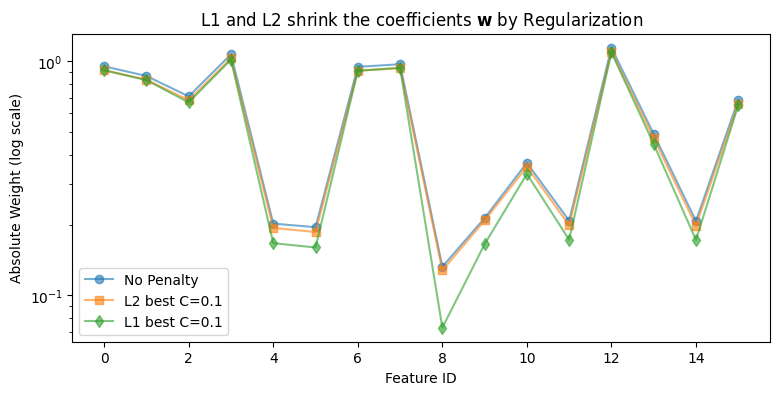

In [24]:
# Grid C, lambda = 1 / C
C_grid = [0.01, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0]

# Stratified 5-fold CV
cv_l2 = tune_logistic_reg_stratified_cv(
    X_bin_train, y_bin_train,
    C_values=C_grid,
    penalty='l2',
    learning_rate=0.1,
    max_epochs=500,
    class_weight='balanced',
    k=5,
    random_state=42,
)

cv_l1 = tune_logistic_reg_stratified_cv(
    X_bin_train, y_bin_train,
    C_values=C_grid,
    penalty='l1',
    learning_rate=0.1,
    max_epochs=500,
    class_weight='balanced',
    k=5,
    random_state=42,
)

display(cv_l2['results_df'].sort_values('mean_accuracy', ascending=False).reset_index(drop=True))
display(cv_l1['results_df'].sort_values('mean_accuracy', ascending=False).reset_index(drop=True))

# Fit on all train dataset with best from CV
lr_no_pen = LogisticRegressionReg(learning_rate=0.1, penalty='l2', C=0.0, max_epochs=500)
lr_no_pen.fit(X_bin_train, y_bin_train)

lr_l2 = LogisticRegressionReg(
    learning_rate=0.1, penalty='l2', C=cv_l2['best_C'],
    max_epochs=500, class_weight='balanced'
)
lr_l2.fit(X_bin_train, y_bin_train)

lr_l1 = LogisticRegressionReg(
    learning_rate=0.1, penalty='l1', C=cv_l1['best_C'],
    max_epochs=500, class_weight='balanced'
)
lr_l1.fit(X_bin_train, y_bin_train)

acc_no_pen = accuracy_score(y_bin_val, lr_no_pen.predict(X_bin_val))
acc_l2 = accuracy_score(y_bin_val, lr_l2.predict(X_bin_val))
acc_l1 = accuracy_score(y_bin_val, lr_l1.predict(X_bin_val))

sparsity_rows = pd.DataFrame([
    {'Model': 'No Penalty', **compute_weight_sparsity(lr_no_pen.w, threshold=1e-3)},
    {'Model': f'L2 (C={cv_l2["best_C"]}, lambda={cv_l2["best_lambda"]:.4f})', **compute_weight_sparsity(lr_l2.w, threshold=1e-3)},
    {'Model': f'L1 (C={cv_l1["best_C"]}, lambda={cv_l1["best_lambda"]:.4f})', **compute_weight_sparsity(lr_l1.w, threshold=1e-3)},
])

print(f"Best L2 C from stratified 5-fold CV: {cv_l2['best_C']} (lambda={cv_l2['best_lambda']:.4f})")
print(f"Best L1 C from stratified 5-fold CV: {cv_l1['best_C']} (lambda={cv_l1['best_lambda']:.4f})")
print(f"Accuracy No Penalty        : {acc_no_pen:.4f}")
print(f"Accuracy L2 (class_weighted) : {acc_l2:.4f}")
print(f"Accuracy L1 (class_weighted) : {acc_l1:.4f}")
display(sparsity_rows)

# Sparsity
plt.figure(figsize=(9, 4))
plt.plot(np.abs(lr_no_pen.w[1:]), 'o-', label='No Penalty', alpha=0.6)
plt.plot(np.abs(lr_l2.w[1:]), 's-', label=f'L2 best C={cv_l2["best_C"]}', alpha=0.6)
plt.plot(np.abs(lr_l1.w[1:]), 'd-', label=f'L1 best C={cv_l1["best_C"]}', alpha=0.6)
plt.title(r"L1 and L2 shrink the coefficients $\mathbf{w}$ by Regularization")
plt.yscale('log')
plt.ylabel('Absolute Weight (log scale)')
plt.xlabel('Feature ID')
plt.legend()
plt.show()


## 4. Cài đặt class-weighted loss

In [ ]:
# Demo class-weighted loss: c_k ∝ N / N_k
from sklearn.metrics import precision_score, recall_score, f1_score

# Build an imbalanced binary training set from existing binary data
# Current encoding: y_bin_* with SIRA=1, DERMASON=0
rng = np.random.default_rng(42)
idx_major = np.where(y_bin_train == 0)[0]  # majority keep all
idx_minor = np.where(y_bin_train == 1)[0]  # minority downsample

minor_keep = max(20, int(0.15 * len(idx_minor)))
idx_minor_keep = rng.choice(idx_minor, size=minor_keep, replace=False)
idx_imb = np.concatenate([idx_major, idx_minor_keep])
rng.shuffle(idx_imb)

X_imb, y_imb = X_bin_train[idx_imb], y_bin_train[idx_imb]

# Class weights c_k proportional to N/N_k (for demonstration print)
N = len(y_imb)
N0 = np.sum(y_imb == 0)
N1 = np.sum(y_imb == 1)
ck0 = N / N0
ck1 = N / N1

print('Imbalanced train distribution:')
print(pd.Series(y_imb).value_counts().sort_index())
print(f'c_0 ~ N/N0 = {ck0:.3f}, c_1 ~ N/N1 = {ck1:.3f}')

# Baseline: no class weight
lr_plain = LogisticRegressionReg(
    learning_rate=0.1,
    penalty='l2',
    C=1.0,
    max_epochs=500,
    class_weight=None,
)
lr_plain.fit(X_imb, y_imb)
pred_plain = lr_plain.predict(X_bin_val)

# Weighted: balanced => c_k proportional to N/N_k
lr_weighted = LogisticRegressionReg(
    learning_rate=0.1,
    penalty='l2',
    C=1.0,
    max_epochs=500,
    class_weight='balanced',
)
lr_weighted.fit(X_imb, y_imb)
pred_weighted = lr_weighted.predict(X_bin_val)

compare_df = pd.DataFrame([
    {
        'Model': 'LR no class weight',
        'Accuracy': accuracy_score(y_bin_val, pred_plain),
        'Precision(minority=1)': precision_score(y_bin_val, pred_plain, pos_label=1, zero_division=0),
        'Recall(minority=1)': recall_score(y_bin_val, pred_plain, pos_label=1, zero_division=0),
        'F1(minority=1)': f1_score(y_bin_val, pred_plain, pos_label=1, zero_division=0),
    },
    {
        'Model': 'LR class_weight=balanced',
        'Accuracy': accuracy_score(y_bin_val, pred_weighted),
        'Precision(minority=1)': precision_score(y_bin_val, pred_weighted, pos_label=1, zero_division=0),
        'Recall(minority=1)': recall_score(y_bin_val, pred_weighted, pos_label=1, zero_division=0),
        'F1(minority=1)': f1_score(y_bin_val, pred_weighted, pos_label=1, zero_division=0),
    },
])

display(compare_df)

plt.figure(figsize=(7, 4))
plt.plot(lr_plain.loss_history, label='No class weight', alpha=0.8)
plt.plot(lr_weighted.loss_history, label='class_weight=balanced', alpha=0.8)
plt.title('Loss curve on imbalanced training set')
plt.xlabel('Epoch')
plt.ylabel('Weighted BCE + regularization')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# IV. Bonus nâng cao


## 1.  Mô hình Probit và Xấp xỉ Laplace (Laplace Approximation)
- **Probit Regression**: Sử dụng hàm xác suất tích lũy (CDF Gaussian chuẩn $\Phi(z)$) để thay cho đường cong Sigmoid $\sigma(z)$. Phù hợp xử lý dữ liệu nơi phân chia bị nhiễu.

In [25]:
# Probit Regression
probit = ProbitRegressionGD(learning_rate=0.1, max_epochs=1000)
probit.fit(X_bin_train, y_bin_train)
acc_probit = accuracy_score(y_bin_val, probit.predict(X_bin_val))


print(f"Accuracy Probit Regression  : {acc_probit:.4f}")

Accuracy Probit Regression  : 0.9266


### 6.2 Xấp xỉ Laplace (Laplace Approximation)
- **Xấp xỉ Laplace**: Giải quyết bài toán Maximum A Posteriori (MAP) phân phối Hậu nghiệm cho Logistic Regression, sau đó tính ma trận hiệp phương sai của xác suất Posterior dựa vào nghịch đảo Hessian $H^{-1}$. Xấp xỉ Laplace có lợi thế khi đi kèm tính toán khoảng bất định (Uncertainty Margin). Nó bớt sai dại tự tin cho điểm sample nằm ở vùng quyết định mơ hồ.

Accuracy Laplace Approxi.   : 0.9288


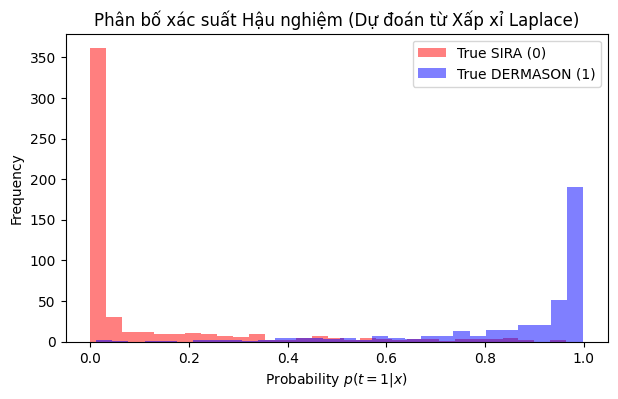

In [26]:
# Laplace Approximation
laplace = LaplaceApproximationLR(lambd=1.0, max_epochs=50)
laplace.fit(X_bin_train, y_bin_train)
acc_laplace = accuracy_score(y_bin_val, laplace.predict(X_bin_val))

prob_pred_laplace = laplace.predict_proba(X_bin_val)[:, 1]

print(f"Accuracy Laplace Approxi.   : {acc_laplace:.4f}")

plt.figure(figsize=(7, 4))
plt.hist(prob_pred_laplace[y_bin_val==0], bins=30, alpha=0.5, label='True SIRA (0)', color='red')
plt.hist(prob_pred_laplace[y_bin_val==1], bins=30, alpha=0.5, label='True DERMASON (1)', color='blue')
plt.title("Phân bố xác suất Hậu nghiệm (Dự đoán từ Xấp xỉ Laplace)")
plt.xlabel("Probability $p(t=1 | x)$")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 6.3 **Kernel Logistic Regression**: cài đặt dual formulation với RBF kernel, so sánh với mô hình tuyến tính trên dữ liệu không phân chia tuyến tính (XOR-like patterns).

Linear Logistic Regression accuracy on XOR-like data : 0.7083
Kernel Logistic Regression (RBF) accuracy            : 1.0000


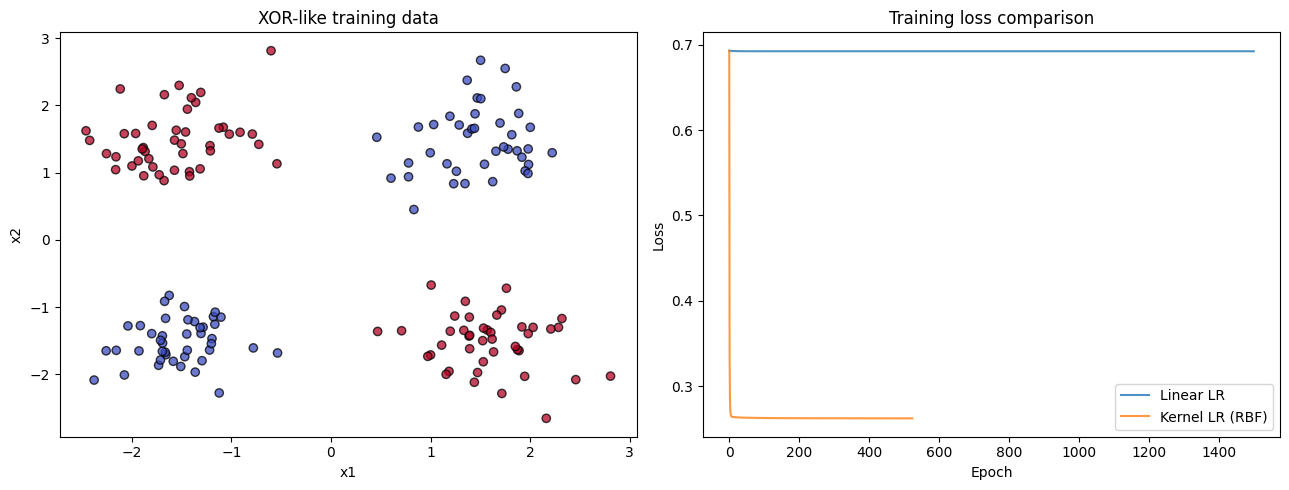

In [27]:
# Kernel Logistic Regression on XOR-like dataset non-separable
X_xor, y_xor = make_kernel_xor_data(n_samples=240, noise=0.45, random_state=42)
X_xor_train, X_xor_test, y_xor_train, y_xor_test = train_test_split_custom(
    X_xor, y_xor, test_size=0.30, random_state=42
)

linear_lr_xor = LogisticRegressionGD(learning_rate=0.1, max_epochs=1500)
linear_lr_xor.fit(X_xor_train, y_xor_train)
acc_linear_xor = accuracy_score(y_xor_test, linear_lr_xor.predict(X_xor_test))

kernel_lr_xor = KernelLogisticRegressionRBF(
    gamma=0.8, lambd=1e-2, learning_rate=0.5, max_epochs=800, tol=1e-7
)
kernel_lr_xor.fit(X_xor_train, y_xor_train)
acc_kernel_xor = accuracy_score(y_xor_test, kernel_lr_xor.predict(X_xor_test))

print(f"Linear Logistic Regression accuracy on XOR-like data : {acc_linear_xor:.4f}")
print(f"Kernel Logistic Regression (RBF) accuracy            : {acc_kernel_xor:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_xor_train[:, 0], X_xor_train[:, 1], c=y_xor_train, cmap='coolwarm', edgecolor='k', alpha=0.75)
axes[0].set_title('XOR-like training data')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

axes[1].plot(linear_lr_xor.loss_history, label='Linear LR', alpha=0.8)
axes[1].plot(kernel_lr_xor.loss_history, label='Kernel LR (RBF)', alpha=0.8)
axes[1].set_title('Training loss comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()


### 6.4 **Gaussian Naive Bayes** vs. **LDA**: so sánh lý thuyết (GNB giả thiết independence, LDA không) và thực nghiệm – khi nào GNB thực tế tốt hơn LDA dù giả thiết kém chặt hơn?

In [28]:
# Gaussian Naive Bayes vs LDA
gnb_lda_rows = []
for case_name, seed in [('correlated_shared_cov', 42), ('independent_small_sample', 7)]:
    n_per_class = 140 if case_name == 'correlated_shared_cov' else 24
    X_case, y_case = make_gnb_lda_demo_data(
        n_samples_per_class=n_per_class,
        case=case_name,
        random_state=seed,
    )
    X_case_train, X_case_test, y_case_train, y_case_test = stratified_train_test_split_custom(
        X_case, y_case, test_size=0.35, random_state=seed
    )

    gnb_case = GaussianNaiveBayesScratch(var_smoothing=1e-9)
    gnb_case.fit(X_case_train, y_case_train)
    lda_case = LDA_Scratch()
    lda_case.fit(X_case_train, y_case_train)

    gnb_acc = accuracy_score(y_case_test, gnb_case.predict(X_case_test))
    lda_acc = accuracy_score(y_case_test, lda_case.predict(X_case_test))
    gnb_lda_rows.append({
        'Scenario': case_name,
        'Train Size': len(y_case_train),
        'Test Size': len(y_case_test),
        'GNB Accuracy': gnb_acc,
        'LDA Accuracy': lda_acc,
        'Better Model': 'GNB' if gnb_acc > lda_acc else 'LDA',
    })

gnb_lda_results = pd.DataFrame(gnb_lda_rows)
display(gnb_lda_results)

bean_classes = np.unique(y_train)
bean_to_int = {cls: idx for idx, cls in enumerate(bean_classes)}
y_train_int = np.array([bean_to_int[v] for v in y_train])
y_val_int = np.array([bean_to_int[v] for v in y_val])

gnb_bean = GaussianNaiveBayesScratch(var_smoothing=1e-9)
gnb_bean.fit(X_train, y_train_int)
lda_bean = LDA_Scratch()
lda_bean.fit(X_train, y_train_int)

print(f"Dry Bean validation accuracy - GNB: {accuracy_score(y_val_int, gnb_bean.predict(X_val)):.4f}")
print(f"Dry Bean validation accuracy - LDA: {accuracy_score(y_val_int, lda_bean.predict(X_val)):.4f}")


,Scenario,Train Size,Test Size,GNB Accuracy,LDA Accuracy,Better Model
0,correlated_shared_cov,273,147,0.891156,0.993197,LDA
1,independent_small_sample,45,27,1.000000,1.000000,LDA


Dry Bean validation accuracy - GNB: 0.8986
Dry Bean validation accuracy - LDA: 0.8941


### 6.5 Phân tích **VC dimension**: tính VC dimension của lớp phân lớp tuyến tính trong $\mathbb{R}^D$ và liên hệ với tổng quát hóa thông qua structural risk minimization.

In [29]:
# VC dimension của lớp phân lớp tuyến tính trong R^D và liên hệ với SRM
feature_slices = [2, 4, X_bin_train.shape[1]]
vc_rows = []
for d in feature_slices:
    model = LogisticRegressionGD(learning_rate=0.1, max_epochs=1500)
    model.fit(X_bin_train[:, :d], y_bin_train)
    train_pred = model.predict(X_bin_train[:, :d])
    val_pred = model.predict(X_bin_val[:, :d])
    train_error = 1.0 - accuracy_score(y_bin_train, train_pred)
    val_accuracy = accuracy_score(y_bin_val, val_pred)
    vc_rows.append({
        'model': f'Linear LR with {d} features',
        'empirical_error': train_error,
        'vc_dim': linear_classifier_vc_dimension(d, include_bias=True),
        'val_accuracy': val_accuracy,
    })

vc_summary = structural_risk_summary(vc_rows, n_samples=len(y_bin_train), delta=0.05)
val_map = {row['model']: row['val_accuracy'] for row in vc_rows}
vc_summary['val_accuracy'] = vc_summary['model'].map(val_map)
display(vc_summary)

full_vc_dim = linear_classifier_vc_dimension(X_bin_train.shape[1], include_bias=True)
print(f"VC dimension of affine linear classifiers in R^{X_bin_train.shape[1]}: {full_vc_dim}")


,model,empirical_error,vc_dim,margin,bound,val_accuracy
0,Linear LR with 2 features,0.086434,3,0.085028,0.171462,0.913700
1,Linear LR with 4 features,0.089438,5,0.103848,0.193286,0.905070
2,Linear LR with 16 features,0.077190,17,0.171546,0.248736,0.926645


VC dimension of affine linear classifiers in R^16: 17


# IV. Tổng hợp đánh giá đầy đủ trên tập test

Phần này báo cáo đầy đủ các chỉ số:
- Accuracy, Precision, Recall, F1-score
- Confusion Matrix (heatmap)
- ROC curve + AUC (bài toán nhị phân)
- Precision-Recall curve + Average Precision (AP)
- Cross-entropy loss theo epochs
- Decision boundary 2D (nếu có thể)
- Bảng so sánh thống nhất giữa các mô hình
- 5-fold cross-validation (mean ± std)
- McNemar's test (so sánh 2 mô hình tốt nhất)
- Calibration (reliability diagram)

=== Bang tong hop chi so tren tap TEST (multiclass) ===


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,AUC_macro_ovr,LogLoss
0,QDA,0.897638,0.926447,0.919945,0.919390,NaN,NaN
1,LDA,0.897638,0.920485,0.913736,0.914461,NaN,NaN
2,Gaussian NB,0.893209,0.905041,0.904080,0.903380,0.991394,1.013239
3,OVO (GD),0.904528,0.903435,0.898652,0.900686,NaN,NaN
4,Softmax (GD),0.892224,0.887716,0.873720,0.879065,0.990449,0.391027
5,OVR (GD),0.853346,0.869801,0.789946,0.792380,0.986285,0.718197



=== Bao cao Precision/Recall/F1 theo tung lop (model dung dau) ===
Model tot nhat theo F1_macro: QDA


,precision,recall,f1-score,support
BARBUNYA,0.961749,0.888889,0.923885,198.000000
BOMBAY,1.000000,1.000000,1.000000,78.000000
CALI,0.906250,0.946939,0.926148,245.000000
DERMASON,0.960739,0.781955,0.862176,532.000000
HOROZ,0.949640,0.946237,0.947935,279.000000
SEKER,0.975610,0.921053,0.947547,304.000000
SIRA,0.731141,0.954545,0.828039,396.000000
accuracy,0.897638,0.897638,0.897638,0.897638
macro avg,0.926447,0.919945,0.919390,2032.000000
weighted avg,0.911731,0.897638,0.899087,2032.000000


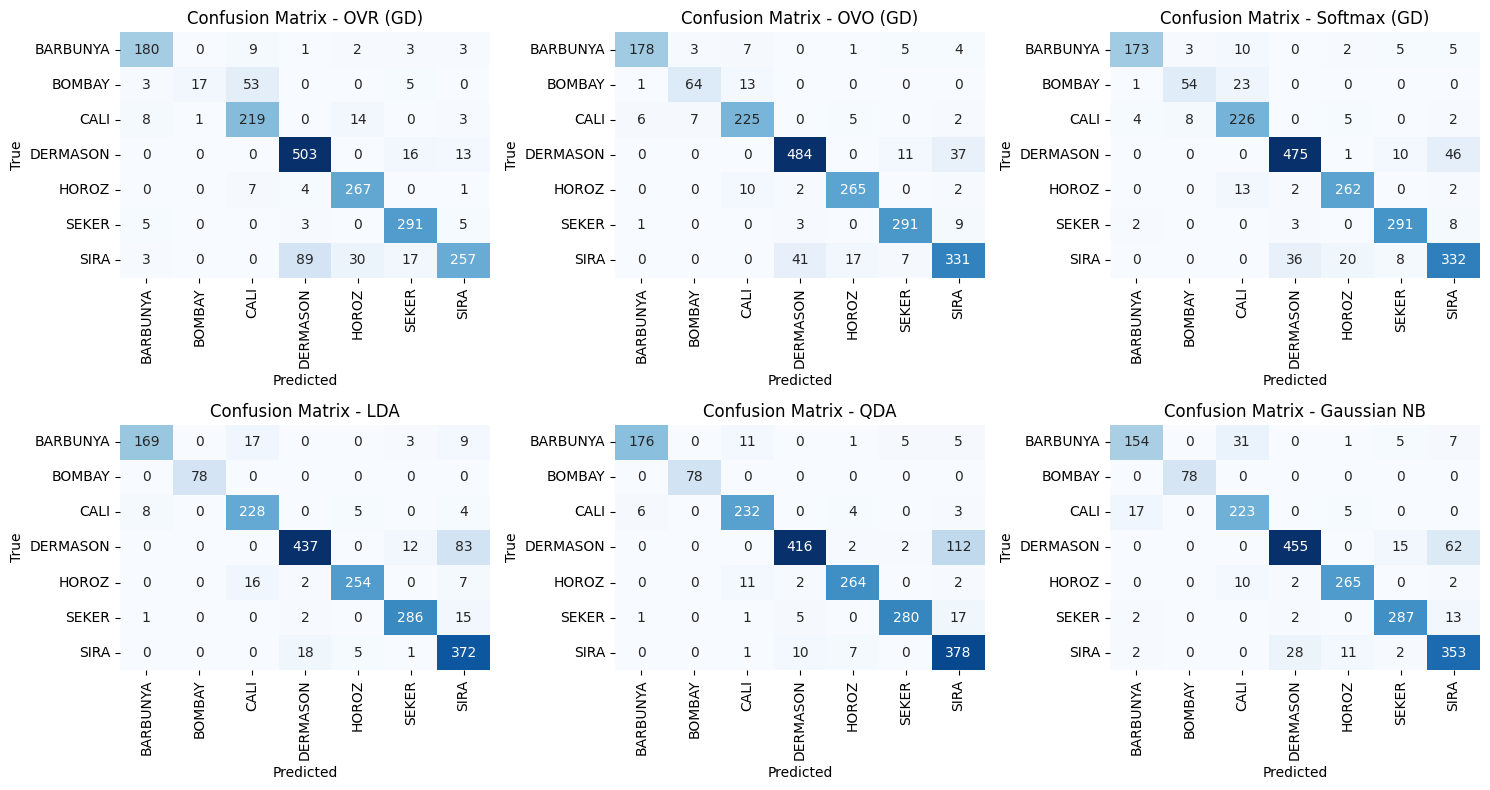

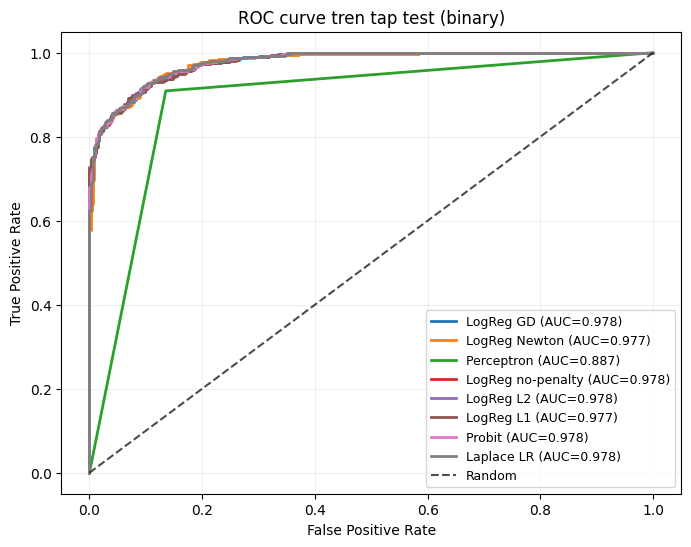

=== Bang tong hop chi so tren tap TEST (binary: DERMASON vs SIRA) ===


,Model,Accuracy,Precision,Recall,F1,AUC,AP
0,LogReg no-penalty,0.912716,0.898734,0.896465,0.897598,0.977539,0.973451
1,Probit,0.909483,0.880488,0.911616,0.895782,0.977662,0.973418
2,LogReg L1,0.907328,0.870813,0.919192,0.894349,0.976926,0.972810
3,LogReg GD,0.908405,0.882064,0.906566,0.894147,0.977605,0.973396
4,LogReg L2,0.906250,0.868735,0.919192,0.893252,0.977553,0.973464
5,Laplace LR,0.906250,0.875912,0.909091,0.892193,0.977686,0.973212
6,LogReg Newton,0.906250,0.879607,0.904040,0.891656,0.976632,0.971952
7,Perceptron,0.883621,0.833333,0.909091,0.869565,0.886876,0.796369


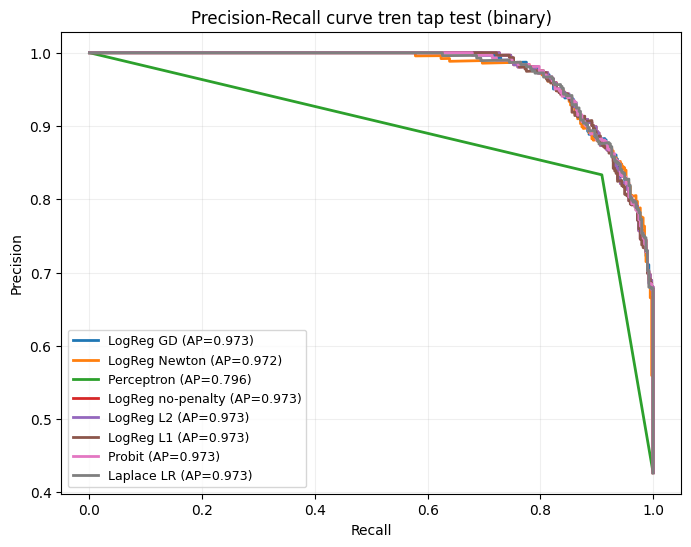

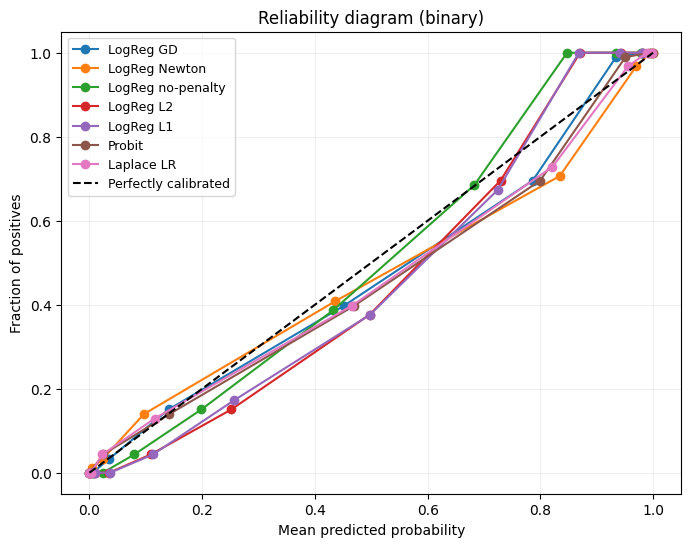

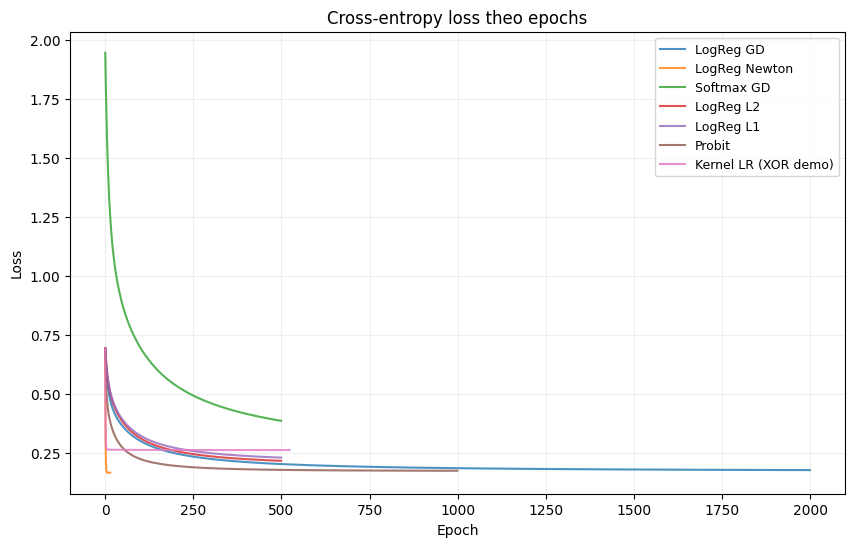

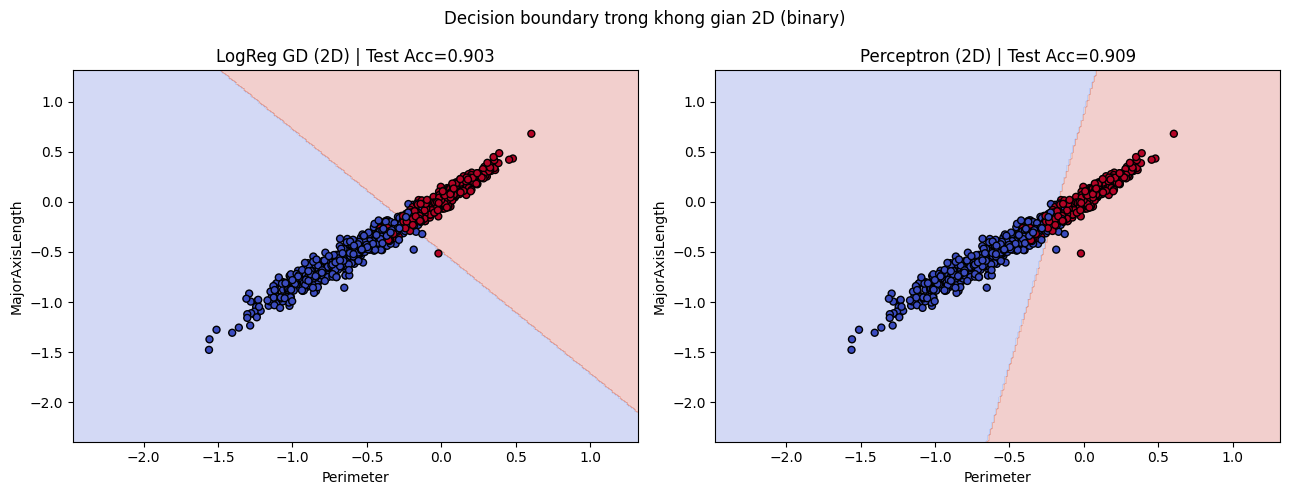

=== 5-fold cross-validation (mean ± std) ===


,Model,Accuracy (mean±std),Precision_macro (mean±std),Recall_macro (mean±std),F1_macro (mean±std),AUC_macro_ovr (mean±std)
0,OVR (GD),0.8645 ± 0.0071,0.8860 ± 0.0100,0.8057 ± 0.0111,0.8144 ± 0.0153,0.9873 ± 0.0015
1,OVO (GD),0.9136 ± 0.0077,0.9201 ± 0.0085,0.9084 ± 0.0110,0.9132 ± 0.0093,N/A
2,Softmax (GD),0.8997 ± 0.0082,0.8996 ± 0.0108,0.8730 ± 0.0173,0.8816 ± 0.0153,0.9918 ± 0.0012
3,LDA,0.9011 ± 0.0055,0.9282 ± 0.0056,0.9158 ± 0.0061,0.9191 ± 0.0058,N/A
4,QDA,0.8978 ± 0.0051,0.9255 ± 0.0051,0.9192 ± 0.0040,0.9188 ± 0.0046,N/A
5,Gaussian NB,0.8956 ± 0.0058,0.9072 ± 0.0063,0.9051 ± 0.0067,0.9054 ± 0.0062,0.9918 ± 0.0005


=== McNemar test tren tap test (2 model top theo F1_macro) ===


,Model_1,Model_2,"n10 (M1 correct, M2 wrong)","n01 (M1 wrong, M2 correct)",Statistic,p_value,Conclusion (alpha=0.05)
0,QDA,LDA,53,53,0.009434,0.922624,Not significantly different


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar


def _safe_predict(model, X):
    return model.predict(X)


def _to_int_labels(y, label_to_int_map):
    y_arr = np.asarray(y)
    if y_arr.dtype.kind in {'U', 'S', 'O'}:
        return np.array([label_to_int_map[v] for v in y_arr], dtype=int)
    return y_arr.astype(int)


def _extract_binary_score(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if np.ndim(proba) == 2 and proba.shape[1] >= 2:
            return proba[:, 1], True
    if hasattr(model, 'decision_function'):
        return model.decision_function(X), False
    y_hat = _safe_predict(model, X)
    return np.asarray(y_hat).astype(float), False


def _extract_multiclass_proba(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if np.ndim(proba) == 2:
            return proba
    return None


# Load raw test labels again to avoid side effects from previous label encoding cells
train_df_eval = pd.read_csv('../../data/classification/processed/dry_bean/train_scaled.csv')
val_df_eval = pd.read_csv('../../data/classification/processed/dry_bean/val_scaled.csv')
test_df_eval = pd.read_csv('../../data/classification/processed/dry_bean/test_scaled.csv')

X_train_eval = train_df_eval.iloc[:, :-1].values
y_train_eval_raw = train_df_eval.iloc[:, -1].values
X_val_eval = val_df_eval.iloc[:, :-1].values
y_val_eval_raw = val_df_eval.iloc[:, -1].values
X_test_eval = test_df_eval.iloc[:, :-1].values
y_test_eval_raw = test_df_eval.iloc[:, -1].values

class_order = np.sort(np.unique(y_train_eval_raw))
label_to_int_eval = {label: i for i, label in enumerate(class_order)}
int_to_label_eval = {i: label for label, i in label_to_int_eval.items()}

y_train_eval = _to_int_labels(y_train_eval_raw, label_to_int_eval)
y_val_eval = _to_int_labels(y_val_eval_raw, label_to_int_eval)
y_test_eval = _to_int_labels(y_test_eval_raw, label_to_int_eval)

# ------------------------------
# A) Unified test-set comparison (multiclass)
# ------------------------------
multiclass_models = {
    'OVR (GD)': ovr_model,
    'OVO (GD)': ovo_model,
    'Softmax (GD)': softmax_model,
    'LDA': lda,
    'QDA': qda,
    'Gaussian NB': gnb_bean,
}

test_rows = []
test_preds = {}
per_class_reports = {}

for name, model_obj in multiclass_models.items():
    pred_raw = _safe_predict(model_obj, X_test_eval)
    pred_int = _to_int_labels(pred_raw, label_to_int_eval)

    test_preds[name] = pred_int
    per_class_reports[name] = pd.DataFrame(
        classification_report(
            y_test_eval,
            pred_int,
            target_names=class_order,
            output_dict=True,
            zero_division=0,
        )
    ).T

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test_eval, pred_int),
        'Precision_macro': precision_score(y_test_eval, pred_int, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_test_eval, pred_int, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test_eval, pred_int, average='macro', zero_division=0),
    }

    proba_mc = _extract_multiclass_proba(model_obj, X_test_eval)
    if proba_mc is not None and proba_mc.shape[1] == len(class_order):
        try:
            row['AUC_macro_ovr'] = roc_auc_score(
                y_test_eval,
                proba_mc,
                multi_class='ovr',
                average='macro',
            )
            row['LogLoss'] = log_loss(y_test_eval, proba_mc, labels=np.arange(len(class_order)))
        except Exception:
            row['AUC_macro_ovr'] = np.nan
            row['LogLoss'] = np.nan
    else:
        row['AUC_macro_ovr'] = np.nan
        row['LogLoss'] = np.nan

    test_rows.append(row)

test_summary = pd.DataFrame(test_rows).sort_values('F1_macro', ascending=False).reset_index(drop=True)
print('=== Bang tong hop chi so tren tap TEST (multiclass) ===')
display(test_summary)

print('\n=== Bao cao Precision/Recall/F1 theo tung lop (model dung dau) ===')
best_name = test_summary.loc[0, 'Model']
print(f'Model tot nhat theo F1_macro: {best_name}')
display(per_class_reports[best_name])

# Confusion matrix heatmaps for all multiclass models
n_models = len(multiclass_models)
ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for idx, (name, pred_int) in enumerate(test_preds.items()):
    cm = confusion_matrix(y_test_eval, pred_int, labels=np.arange(len(class_order)))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        cbar=False,
        xticklabels=class_order,
        yticklabels=class_order,
    )
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# ------------------------------
# B) Binary metrics + ROC/AUC + PR/AP + calibration
# ------------------------------
mask_bin_train = np.isin(y_train_eval_raw, ['DERMASON', 'SIRA'])
mask_bin_test = np.isin(y_test_eval_raw, ['DERMASON', 'SIRA'])

X_bin_train_eval = X_train_eval[mask_bin_train]
y_bin_train_eval = (y_train_eval_raw[mask_bin_train] == 'SIRA').astype(int)
X_bin_test_eval = X_test_eval[mask_bin_test]
y_bin_test_eval = (y_test_eval_raw[mask_bin_test] == 'SIRA').astype(int)

binary_models = {
    'LogReg GD': model_gd,
    'LogReg Newton': model_nt,
    'Perceptron': perceptron,
    'LogReg no-penalty': lr_no_pen,
    'LogReg L2': lr_l2,
    'LogReg L1': lr_l1,
    'Probit': probit,
    'Laplace LR': laplace,
}

binary_rows = []
calibration_candidates = {}

plt.figure(figsize=(8, 6))
for name, m in binary_models.items():
    y_pred = _safe_predict(m, X_bin_test_eval)
    y_pred = np.asarray(y_pred).astype(int)
    y_score, has_proba = _extract_binary_score(m, X_bin_test_eval)

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_bin_test_eval, y_pred),
        'Precision': precision_score(y_bin_test_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_bin_test_eval, y_pred, zero_division=0),
        'F1': f1_score(y_bin_test_eval, y_pred, zero_division=0),
    }

    try:
        auc_val = roc_auc_score(y_bin_test_eval, y_score)
        row['AUC'] = auc_val
        fpr, tpr, _ = roc_curve(y_bin_test_eval, y_score)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.3f})')
    except Exception:
        row['AUC'] = np.nan

    try:
        ap_val = average_precision_score(y_bin_test_eval, y_score)
        row['AP'] = ap_val
    except Exception:
        row['AP'] = np.nan

    if has_proba:
        calibration_candidates[name] = y_score

    binary_rows.append(row)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve tren tap test (binary)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.2)
plt.show()

binary_summary = pd.DataFrame(binary_rows).sort_values('F1', ascending=False).reset_index(drop=True)
print('=== Bang tong hop chi so tren tap TEST (binary: DERMASON vs SIRA) ===')
display(binary_summary)

# Precision-Recall curves
plt.figure(figsize=(8, 6))
for name, m in binary_models.items():
    y_score, _ = _extract_binary_score(m, X_bin_test_eval)
    try:
        precision_c, recall_c, _ = precision_recall_curve(y_bin_test_eval, y_score)
        ap_val = average_precision_score(y_bin_test_eval, y_score)
        plt.plot(recall_c, precision_c, lw=2, label=f'{name} (AP={ap_val:.3f})')
    except Exception:
        pass

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve tren tap test (binary)')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.2)
plt.show()

# Reliability diagram (calibration)
plt.figure(figsize=(8, 6))
for name, prob_pos in calibration_candidates.items():
    frac_pos, mean_pred = calibration_curve(y_bin_test_eval, prob_pos, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability diagram (binary)')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.2)
plt.show()

# ------------------------------
# C) Loss curves by epochs
# ------------------------------
loss_models = {
    'LogReg GD': model_gd,
    'LogReg Newton': model_nt,
    'Softmax GD': softmax_model,
    'Perceptron': perceptron,
    'LogReg L2': lr_l2,
    'LogReg L1': lr_l1,
    'Probit': probit,
    'Laplace LR': laplace,
    'Kernel LR (XOR demo)': kernel_lr_xor,
}

plt.figure(figsize=(10, 6))
for name, m in loss_models.items():
    if hasattr(m, 'loss_history') and len(m.loss_history) > 0:
        plt.plot(m.loss_history, label=name, alpha=0.8)
plt.title('Cross-entropy loss theo epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.2)
plt.show()

# ------------------------------
# D) 2D decision boundary (if possible)
# ------------------------------
if 'fisher_df' in globals() and len(fisher_df) >= 2:
    top2_features = fisher_df['feature'].head(2).tolist()
else:
    top2_features = train_df_eval.columns[:-1].tolist()[:2]

top2_idx = [train_df_eval.columns.get_loc(top2_features[0]), train_df_eval.columns.get_loc(top2_features[1])]
X2_train = X_bin_train_eval[:, top2_idx]
X2_test = X_bin_test_eval[:, top2_idx]

boundary_factories = {
    'LogReg GD (2D)': lambda: LogisticRegressionGD(learning_rate=0.1, max_epochs=1200),
    'Perceptron (2D)': lambda: Perceptron(learning_rate=0.05, max_epochs=1200),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, factory) in zip(axes, boundary_factories.items()):
    mdl = factory()
    mdl.fit(X2_train, y_bin_train_eval)

    x_min, x_max = X2_train[:, 0].min() - 0.8, X2_train[:, 0].max() + 0.8
    y_min, y_max = X2_train[:, 1].min() - 0.8, X2_train[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = mdl.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(X2_test[:, 0], X2_test[:, 1], c=y_bin_test_eval, cmap='coolwarm', edgecolors='k', s=25)
    acc2 = accuracy_score(y_bin_test_eval, mdl.predict(X2_test))
    ax.set_title(f'{name} | Test Acc={acc2:.3f}')
    ax.set_xlabel(top2_features[0])
    ax.set_ylabel(top2_features[1])

plt.suptitle('Decision boundary trong khong gian 2D (binary)')
plt.tight_layout()
plt.show()

# ------------------------------
# E) 5-fold cross-validation (mean ± std)
# ------------------------------
cv_factories = {
    'OVR (GD)': lambda: OneVsRestClassifier(estimator=LogisticRegressionGD(learning_rate=0.1, max_epochs=500)),
    'OVO (GD)': lambda: OneVsOneClassifier(estimator=LogisticRegressionGD(learning_rate=0.1, max_epochs=500)),
    'Softmax (GD)': lambda: LogisticRegressionGD(learning_rate=0.1, max_epochs=500, multi_class='multinomial'),
    'LDA': lambda: LDA_Scratch(),
    'QDA': lambda: QDA_Scratch(),
    'Gaussian NB': lambda: GaussianNaiveBayesScratch(var_smoothing=1e-9),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for name, factory in cv_factories.items():
    fold_metrics = []
    for tr_idx, te_idx in skf.split(X_train_eval, y_train_eval):
        model_cv = factory()
        model_cv.fit(X_train_eval[tr_idx], y_train_eval[tr_idx])
        pred_cv = model_cv.predict(X_train_eval[te_idx])
        pred_cv = np.asarray(pred_cv).astype(int)

        metric_pack = {
            'accuracy': accuracy_score(y_train_eval[te_idx], pred_cv),
            'precision_macro': precision_score(y_train_eval[te_idx], pred_cv, average='macro', zero_division=0),
            'recall_macro': recall_score(y_train_eval[te_idx], pred_cv, average='macro', zero_division=0),
            'f1_macro': f1_score(y_train_eval[te_idx], pred_cv, average='macro', zero_division=0),
        }

        proba_cv = _extract_multiclass_proba(model_cv, X_train_eval[te_idx])
        if proba_cv is not None and proba_cv.shape[1] == len(class_order):
            try:
                metric_pack['auc_macro_ovr'] = roc_auc_score(
                    y_train_eval[te_idx],
                    proba_cv,
                    multi_class='ovr',
                    average='macro',
                )
            except Exception:
                metric_pack['auc_macro_ovr'] = np.nan
        else:
            metric_pack['auc_macro_ovr'] = np.nan

        fold_metrics.append(metric_pack)

    fold_df = pd.DataFrame(fold_metrics)
    cv_rows.append({
        'Model': name,
        'Accuracy (mean±std)': f"{fold_df['accuracy'].mean():.4f} ± {fold_df['accuracy'].std(ddof=1):.4f}",
        'Precision_macro (mean±std)': f"{fold_df['precision_macro'].mean():.4f} ± {fold_df['precision_macro'].std(ddof=1):.4f}",
        'Recall_macro (mean±std)': f"{fold_df['recall_macro'].mean():.4f} ± {fold_df['recall_macro'].std(ddof=1):.4f}",
        'F1_macro (mean±std)': f"{fold_df['f1_macro'].mean():.4f} ± {fold_df['f1_macro'].std(ddof=1):.4f}",
        'AUC_macro_ovr (mean±std)': (
            f"{fold_df['auc_macro_ovr'].mean():.4f} ± {fold_df['auc_macro_ovr'].std(ddof=1):.4f}"
            if fold_df['auc_macro_ovr'].notna().any()
            else 'N/A'
        ),
    })

cv_summary = pd.DataFrame(cv_rows)
print('=== 5-fold cross-validation (mean ± std) ===')
display(cv_summary)

# ------------------------------
# F) McNemar's test (top-2 models on test)
# ------------------------------
ranked_models = test_summary['Model'].tolist()
if len(ranked_models) >= 2:
    m1, m2 = ranked_models[0], ranked_models[1]
    p1 = test_preds[m1]
    p2 = test_preds[m2]
    correct1 = (p1 == y_test_eval)
    correct2 = (p2 == y_test_eval)

    n11 = int(np.sum(correct1 & correct2))
    n10 = int(np.sum(correct1 & (~correct2)))
    n01 = int(np.sum((~correct1) & correct2))
    n00 = int(np.sum((~correct1) & (~correct2)))

    table = [[n11, n10], [n01, n00]]
    res = mcnemar(table, exact=(n10 + n01 < 25), correction=True)

    mcnemar_df = pd.DataFrame({
        'Model_1': [m1],
        'Model_2': [m2],
        'n10 (M1 correct, M2 wrong)': [n10],
        'n01 (M1 wrong, M2 correct)': [n01],
        'Statistic': [res.statistic],
        'p_value': [res.pvalue],
        'Conclusion (alpha=0.05)': ['Different' if res.pvalue < 0.05 else 'Not significantly different'],
    })

    print('=== McNemar test tren tap test (2 model top theo F1_macro) ===')
    display(mcnemar_df)
else:
    print('Khong du so luong mo hinh de chay McNemar test.')